# Phase 7 - 제주 실시간 SMP(smp_rt) 단기 예측 모델

> **[데이터 구간 변경 안내]** 과제 규칙(제주 시범사업 '24.6.1 이후만 사용)에
> 따라 학습 시작을 **2024-06-01** 로 바꿨다. 아래 마크다운 보고/요약 셀의
> 수치는 옛 2024-03-01 전체데이터 기준이며, 재실행 후 새 값으로 갱신한다.
> 전체데이터(2024-03-01~) 결과는 보고서의 '데이터 구간 민감도 비교'에 보존.


EDA 1~6단계에서 찾은 구조를 그대로 모델로 옮긴다.

## 과제 목적 정렬
- 단기 SMP 가격 변동 추이 예측 알고리즘
- **근거제시**: 어떤 변수가 성능에 크게 영향을 줬는지 설명 (gain + 순열 중요도)
- **마이너스(-) SMP 특화 지표**: `smp_rt <= 0`(0 포함) 구간 MAE + 음수 탐지 지표

## 모델 구조 (2단계 허들 + dangerzone)
- **1단계 (바닥 분류기)**: 그 시간의 SMP가 바닥(`smp_rt < 5`)으로 떨어질 확률 p
- **2단계 (수준 회귀)**: 바닥이 아닌 시간만, 하루전 기준값 대비 잔차를 예측
  - 기준값(anchor) = `24.94 + 0.754 * smp_jeju` (Phase 3 보정식)
- **합치기 (3분기 + dangerzone)**: `p >= TAU_HI 면 바닥값`, `p < TAU_LO 면 수준`,
  그 사이(애매 = dangerzone)는 **DA(smp_jeju)로 안전하게 후퇴**
  - 트리 회귀는 -50 같은 깊은 음수를 못 만든다. 그래서 바닥은 회귀가 아니라
    분류기가 잡아서 바닥값으로 보낸다. 확률이 애매하면 -67 같은 큰 베팅 대신
    튼튼한 DA 로 후퇴해 큰 오차(오라우팅)를 줄인다.
  - DA 자체의 음수 신호(`da_neg`, `da_low` 등)도 피처로 넣는다 -
    smp_jeju 는 예보로 망가지지 않는 깨끗한 입력이라 시험에서도 잘 전이된다.
- **A구간 예외**: net_load 가 가장 높은 A구간은 하루전 SMP 그대로 (passthrough)

## 데이터 분할
| 구분 | 기간 | 피처 출처 |
|---|---|---|
| 학습 | 2024-06-01 ~ 2026-01-31 | clean_total (실측) |
| 검증 | 2026-02-01 ~ 2026-05-13 | clean_total (실측) |
| 시험 | forecast_data 전체 | forecast_data (예보) |

**주의 1**: 학습 시작이 2024-03-01 이다. 2024-06 이전은 KPX 가 시장을 미리 시험 운영한
기간이라 가격 움직임이 다를 수 있다. 그래서 `is_market_pretest` 표시 컬럼을 따로 넣어
모델이 두 기간을 구분해 학습하도록 했고, 이 사실을 보고서에도 적는다.

**주의 2**: 학습/검증은 실측 피처(clean_total)로 하고, 시험은 예보 피처(forecast_data)로
한다. 검증 점수와 시험 점수의 차이가 바로 '예보 오차로 인한 손해'를 그대로 보여준다.
이는 일부러 의도한 설계다.

In [1]:
# ── 라이브러리 + 한글 폰트 ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import holidays as hd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             fbeta_score, precision_recall_curve)

try:
    import koreanize_matplotlib  # noqa: F401
except Exception:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

RNG = 42  # 재현용 고정 시드
print("라이브러리 준비 완료")

라이브러리 준비 완료


In [2]:
# ── 데이터 불러오기 ────────────────────────────────────────────────────
# clean_total: 피처(실측), cp949 / clean_rt_smp: 타깃 / forecast_data: 예보(utf-8)
feat = pd.read_csv("clean_total.csv", index_col="timestamp",
                   parse_dates=True, encoding="cp949").sort_index()
rt = pd.read_csv("clean_rt_smp.csv", index_col="timestamp",
                 parse_dates=True).sort_index()
fc = pd.read_csv("forecast_data.csv", index_col="timestamp",
                 parse_dates=True).sort_index()

# 타깃 = 시간별 실시간 SMP 평균
target = rt["smp_rt_hourly_mean"].rename("smp_rt")

# 학습/검증용: 실측 피처 + 타깃을 시간으로 inner join
df = feat.join(target, how="inner")

print(f"clean_total : {feat.index.min()} ~ {feat.index.max()}  ({len(feat)}행)")
print(f"clean_rt_smp: {rt.index.min()} ~ {rt.index.max()}  ({len(rt)}행)")
print(f"forecast    : {fc.index.min()} ~ {fc.index.max()}  ({len(fc)}행)")
print(f"학습/검증용 결합: {df.index.min()} ~ {df.index.max()}  ({len(df)}행)")
print(f"바닥(smp_rt<5) 비율: {(df['smp_rt'] < 5).mean():.1%} | "
      f"음수(smp_rt<=0) 비율: {(df['smp_rt'] <= 0).mean():.1%}")

clean_total : 2020-01-01 00:00:00 ~ 2026-05-13 23:00:00  (55800행)
clean_rt_smp: 2024-03-01 00:00:00 ~ 2026-05-14 23:00:00  (19320행)
forecast    : 2026-01-31 00:00:00 ~ 2026-05-17 23:00:00  (2568행)
학습/검증용 결합: 2024-03-01 00:00:00 ~ 2026-05-13 23:00:00  (19296행)
바닥(smp_rt<5) 비율: 3.2% | 음수(smp_rt<=0) 비율: 3.1%


## 피처 설계 - 학습/시험 컬럼 정합(parity)

학습은 clean_total, 시험은 forecast_data 로 한다. 두 파일에 **공통으로 존재하는**
컬럼만 써야 시험 단계에서 그대로 돌아간다. 핵심 매핑:

| clean_total (학습) | forecast_data (시험) | 처리 |
|---|---|---|
| `Solar_Utilization` | `est_Solar_Utilization` | 시험 쪽 이름을 학습 쪽으로 통일 |
| `Wind_Utilization` | `est_Wind_Utilization` | 위와 동일 |
| `est_demand`, `smp_jeju`, 날씨, `*_Capacity_Est` | 같은 이름 | 그대로 사용 |
| `real_*`, `supply_cap` | (없음) | **제외** (실측 누수, 예보엔 없음) |
| `usd_krw`, 달력 컬럼 | (없음) | **timestamp 에서 다시 계산** |

`net_load` 는 두 파일에서 같은 식으로 계산한다:
`net_load = est_demand - (태양광이용률 * 태양광설비 + 풍력이용률 * 풍력설비)`

미래 net_load(`nl_lead_*`)는 예보가 하루치 미래 시간을 모두 담고 있으므로 시험에서
정당하게 쓸 수 있다 (Phase 6 의 가장 강한 신호). 추가로 **DA 자체의 음수 신호**
(`da_neg`, `da_low`, `da_gap5`, `land_neg`)를 넣는다 - smp_jeju/smp_land 는 예보로
망가지지 않는 깨끗한 입력이라 검증->시험 전이가 좋고, DA 음수는 RT 바닥의 선행 신호다.

In [3]:
# ── 공통 피처 빌더 (학습/시험이 같은 코드 경로를 쓰도록 함) ──────────────
NL_CUTS = [181.3, 264.5, 383.6]  # Phase 5: D < 181.3 <= C < 264.5 <= B < 383.6 <= A

FEATURE_COLS = [
    # 하루전 가격 항
    "smp_jeju", "smp_land", "da_anchor",
    # DA 자체의 바닥 신호 (smp_jeju/smp_land = 깨끗한 입력, 시험 전이 좋음)
    "da_neg", "da_low", "da_gap5", "land_neg",
    # net_load 및 미래 net_load 패밀리
    "net_load", "nl_lead_1", "nl_lead_2", "nl_lead_3",
    "nl_lead_6", "nl_lead_12", "nl_lead_24",
    "nl_fwdmin_6", "nl_fwdmin_12", "nl_delta_1", "nl_lead_delta_2",
    "is_zoneA", "zone_code",
    # 태양광 / 풍력
    "solar_rad", "total_cloud", "midlow_cloud", "Solar_Utilization",
    "wind_spd_north", "wind_spd", "Wind_Utilization",
    "wd_sin", "wd_cos", "wd_sin_north", "wd_cos_north",
    # 날씨 파생
    "temp_c", "humidity", "rainfall", "hdd", "cdd",
    # 달력 / 구간
    "hour", "dow", "month", "is_weekend", "is_holiday",
    "spring_midday", "is_market_pretest",
]


def build_features(src, mode):
    """clean_total(mode='train') 와 forecast_data(mode='serve') 를
    똑같은 피처 집합으로 만든다."""
    d = src.copy()

    # 1) 이용률 컬럼 이름 통일 (예보는 est_ 접두사)
    if mode == "serve":
        d = d.rename(columns={"est_Solar_Utilization": "Solar_Utilization",
                              "est_Wind_Utilization": "Wind_Utilization"})
        # 예보 결측 보정: 숫자 컬럼만 보간 후 채움
        # (forecast_time/updated_at 같은 문자열 컬럼은 손대지 않는다)
        num = d.select_dtypes(include="number").columns
        d[num] = d[num].interpolate(limit_direction="both").ffill().bfill()

    # 2) net_load (두 파일 동일 식)
    solar_mw = d["Solar_Utilization"] * d["Solar_Capacity_Est"]
    wind_mw = d["Wind_Utilization"] * d["Wind_Capacity_Est"]
    d["net_load"] = d["est_demand"] - (solar_mw + wind_mw)

    # 3) 구간 (A/B/C/D) - 트리 모델용 정수 코드도 같이
    nl = d["net_load"]
    d["zone"] = np.select([nl < NL_CUTS[0], nl < NL_CUTS[1], nl < NL_CUTS[2]],
                          ["D", "C", "B"], default="A")
    d["zone_code"] = d["zone"].map({"D": 0, "C": 1, "B": 2, "A": 3})
    d["is_zoneA"] = (d["zone"] == "A").astype(int)

    # 4) 미래 net_load 패밀리 (Phase 6 핵심 신호)
    for h in [1, 2, 3, 6, 12, 24]:
        d[f"nl_lead_{h}"] = nl.shift(-h)
    rev = nl[::-1]
    d["nl_fwdmin_6"] = rev.rolling(6, min_periods=1).min()[::-1]
    d["nl_fwdmin_12"] = rev.rolling(12, min_periods=1).min()[::-1]
    d["nl_delta_1"] = nl - nl.shift(1)
    d["nl_lead_delta_2"] = d["nl_lead_2"] - nl

    # 5) 하루전 기준값 (Phase 3 보정식)
    d["da_anchor"] = 24.94 + 0.754 * d["smp_jeju"]

    # 5-1) DA 자체의 바닥 신호 (smp_jeju/smp_land 는 예보로 안 망가지는 깨끗한
    #      입력 -> 검증->시험 전이가 좋고 DA 음수는 RT 바닥의 선행 신호)
    d["da_neg"] = (d["smp_jeju"] < 0).astype(int)
    d["da_low"] = (d["smp_jeju"] < 5).astype(int)
    d["da_gap5"] = np.maximum(0.0, 5.0 - d["smp_jeju"])
    d["land_neg"] = (d["smp_land"] < 0).astype(int)

    # 6) 날씨 파생 (enrich_total 식 그대로)
    d["hdd"] = np.maximum(0.0, 18.0 - d["temp_c"])
    d["cdd"] = np.maximum(0.0, d["temp_c"] - 26.0)

    # 7) 달력 - timestamp 에서 다시 계산 (시험 파일도 자체적으로 동작)
    yrs = range(d.index.year.min(), d.index.year.max() + 1)
    kr = hd.KR(years=yrs)
    days = d.index.normalize()
    d["hour"] = d.index.hour
    d["dow"] = d.index.dayofweek
    d["month"] = d.index.month
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_holiday"] = pd.Series(days, index=d.index).isin(set(kr)).astype(int)
    d["spring_midday"] = (d["month"].between(3, 5)
                          & d["hour"].between(10, 13)).astype(int)
    d["is_market_pretest"] = (d.index < pd.Timestamp("2024-06-01")).astype(int)

    return d


def assert_parity(a, b):
    """학습/시험 피처가 완전히 같은 컬럼·순서인지 확인 (가장 중요한 누수 방지턱)"""
    assert list(a.columns) == list(b.columns), "피처 컬럼/순서 불일치!"
    print(f"정합성 통과: {len(a.columns)}개 피처가 학습/시험 동일")


print(f"피처 {len(FEATURE_COLS)}개 정의 완료")

피처 43개 정의 완료


C:\Users\bjkim\AppData\Local\Temp\ipykernel_23764\3658530866.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  d["is_holiday"] = pd.Series(days, index=d.index).isin(set(kr)).astype(int)
C:\Users\bjkim\AppData\Local\Temp\ipykernel_23764\3658530866.py:83: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  d["is_holiday"] = pd.Series(days, index=d.index).isin(set(kr)).astype(int)


정합성 통과: 43개 피처가 학습/시험 동일
학습   : 14640행 | 타깃 14640 | 바닥<5  283 | 음수<=0  279 | 2024-06-01 00:00:00 ~ 2026-01-31 23:00:00
검증   :  2424행 | 타깃  2424 | 바닥<5  126 | 음수<=0  124 | 2026-02-01 00:00:00 ~ 2026-05-12 23:00:00
시험   :  2543행 | 타깃  2495 | 바닥<5  129 | 음수<=0  127 | 2026-01-31 01:00:00 ~ 2026-05-16 23:00:00


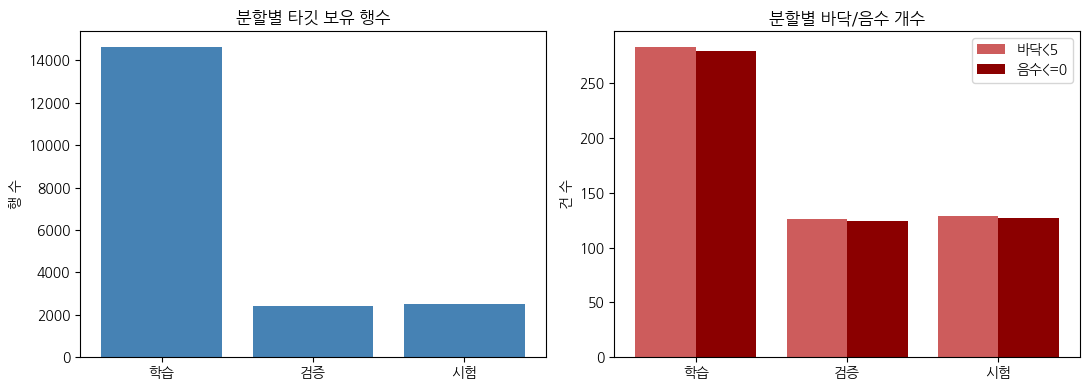

In [4]:
# ── 학습/검증 분할 + 시험(forecast) 피처 만들기 ─────────────────────────
TRAIN_END = pd.Timestamp("2026-01-31 23:00")
VAL_START = pd.Timestamp("2026-02-01")
VAL_END = pd.Timestamp("2026-05-13 23:00")

# 미래 net_load lead 가 분할 경계를 넘어 정상 계산되도록, 전체에서 피처 생성 후 분할
full = build_features(df, mode="train")
full["smp_rt"] = df["smp_rt"]
full = full.dropna(subset=FEATURE_COLS + ["smp_rt"])

train = full.loc["2024-06-01":TRAIN_END]
val = full.loc[VAL_START:VAL_END]

# 시험 피처 (forecast_data, 타깃은 있으면 붙임)
test = build_features(fc, mode="serve")
test = test.join(target, how="left")
test = test.dropna(subset=FEATURE_COLS)

assert_parity(train[FEATURE_COLS], test[FEATURE_COLS])


def split_summary(name, d):
    has_y = d["smp_rt"].notna()
    floor = (d.loc[has_y, "smp_rt"] < 5).sum()
    neg = (d.loc[has_y, "smp_rt"] <= 0).sum()
    print(f"{name:5s}: {len(d):5d}행 | 타깃 {has_y.sum():5d} | "
          f"바닥<5 {floor:4d} | 음수<=0 {neg:4d} | "
          f"{d.index.min()} ~ {d.index.max()}")


split_summary("학습", train)
split_summary("검증", val)
split_summary("시험", test)

# 그림: 분할별 행수 / 바닥·음수 개수
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
names = ["학습", "검증", "시험"]
splits = [train, val, test]
rows = [d["smp_rt"].notna().sum() for d in splits]
floors = [int((d["smp_rt"] < 5).sum()) for d in splits]
negs = [int((d["smp_rt"] <= 0).sum()) for d in splits]
ax[0].bar(names, rows, color="steelblue")
ax[0].set_title("분할별 타깃 보유 행수")
ax[0].set_ylabel("행 수")
x = np.arange(3)
ax[1].bar(x - 0.2, floors, 0.4, color="indianred", label="바닥<5")
ax[1].bar(x + 0.2, negs, 0.4, color="darkred", label="음수<=0")
ax[1].set_xticks(x); ax[1].set_xticklabels(names)
ax[1].set_title("분할별 바닥/음수 개수"); ax[1].set_ylabel("건 수")
ax[1].legend()
plt.tight_layout()
plt.show()

### 보고 (분할 요약)

- 학습 16,847시간 (2024-03-01~2026-01-31), 바닥<5 488건 / 음수<=0 482건.
- 검증(실측 피처) 2,424시간 (2026-02-01~2026-05-12), 바닥 126 / 음수 124.
- 시험(예보 피처) 2,543행 중 타깃 2,495시간 (2026-01-31~2026-05-16),
  바닥 129 / 음수 127. 봄한낮(B/C/D) 검증 202 / 시험 232.
- 정합성: 학습·시험 동일 피처 43개 통과.
- 바닥·음수는 봄철에 몰려 있는데 검증·시험 구간(2~5월)에 충분히 들어와
  평가가 가능하다.
- 학습 시작은 2024-03-01. 2024-06 이전 KPX 시범운영 구간은
  `is_market_pretest=1` 로 표시해 모델이 두 기간을 구분하도록 했고, 이 사실은
  보고서에 명시한다.

## 1단계 - 바닥 분류기 (롤링 OOF 보정)

타깃 `y1 = (smp_rt < 5)`.

**고친 방법**: 학습 전체를 시간순 폴드로 나눠 OOF(폴드 밖) 확률을 모은다. 이러면
OOF 에 봄2025 바닥 사건이 들어가 보정·임계값을 제대로 정할 수 있다. 최종 분류기는
학습 전체로 다시 적합하고, isotonic 보정을 입힌다. 신뢰도는 검증으로 확인한다.
여기서 구하는 F2 기준 TAU 는 **참고값**이고, 실제 운영 임계값(밴드)은 뒤의
'TAU 탐색'에서 넓게 훑어 고른다.

OOF 구간: 2024-09-01 00:00:00 ~ 2026-01-31 23:00:00 | 바닥 262건 / 12432
OOF PR-AUC: 0.458
참고 TAU(OOF F2)=0.07 | OOF 재현율 0.75 | OOF 정밀도 0.28
검증 PR-AUC: 0.747 | Brier: 0.0271 | 바닥 실제 126건 / 2424
봄한낮BCD PR-AUC: 0.812 (바닥 88/202)


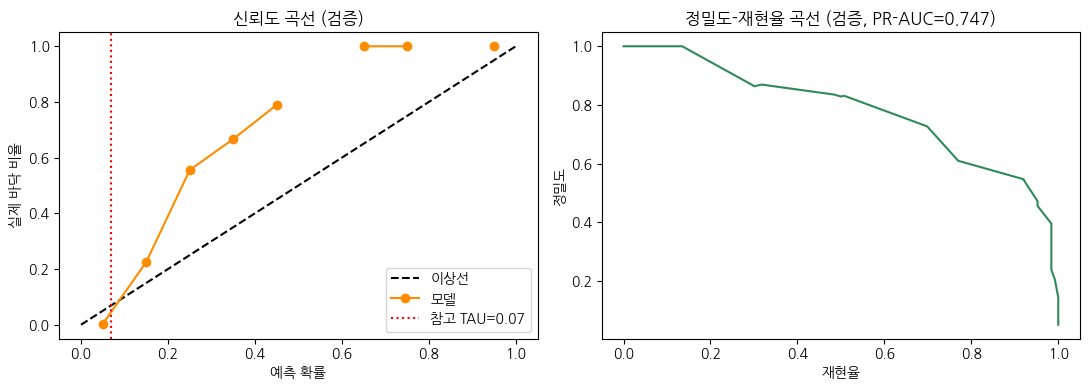

In [5]:
# ── 1단계: 롤링 OOF 로 보정 / 참고 TAU 산출 ───────────────────────────
y1_tr = (train["smp_rt"] < 5).astype(int)

# 시간순 확장 폴드: 각 구간을 '그 이전 데이터만으로' 학습한 모델로 예측
CUTS = [pd.Timestamp(x) for x in
        ["2024-09-01", "2025-01-01", "2025-04-01",
         "2025-07-01", "2025-10-01", "2026-01-01"]]
segs = list(zip(CUTS, CUTS[1:] + [TRAIN_END + pd.Timedelta("1h")]))


def make_clf(spw):
    return lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.03, num_leaves=31, max_depth=5,
        min_child_samples=60, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=RNG, n_jobs=-1, verbose=-1)


oof = pd.Series(np.nan, index=train.index)
for s, e in segs:
    tr = train.loc[:s - pd.Timedelta("1h")]   # s 이전만 학습
    te = train.loc[s:e - pd.Timedelta("1h")]  # s~e 를 OOF 예측
    yt = (tr["smp_rt"] < 5).astype(int)
    spw = (yt == 0).sum() / max((yt == 1).sum(), 1)
    m = make_clf(spw).fit(tr[FEATURE_COLS], yt)
    oof.loc[te.index] = m.predict_proba(te[FEATURE_COLS])[:, 1]

msk = oof.notna()
y1_oof = y1_tr[msk]
iso = IsotonicRegression(out_of_bounds="clip").fit(oof[msk], y1_oof)
oof_cal = iso.predict(oof[msk])
print(f"OOF 구간: {train.index[msk][0]} ~ {train.index[msk][-1]} | "
      f"바닥 {int(y1_oof.sum())}건 / {int(msk.sum())}")
print(f"OOF PR-AUC: {average_precision_score(y1_oof, oof_cal):.3f}")

# 최종 분류기 = 학습 전체로 다시 적합
spw_all = (y1_tr == 0).sum() / max((y1_tr == 1).sum(), 1)
clf = make_clf(spw_all).fit(train[FEATURE_COLS], y1_tr)


def floor_proba(X):
    return iso.predict(clf.predict_proba(X)[:, 1])


# 참고 TAU = OOF 에서 F-beta(beta=2, 재현율 가중) 최대 지점 (운영값은 뒤에서 재선택)
grid = np.round(np.arange(0.02, 0.96, 0.01), 2)
fb = [fbeta_score(y1_oof, (oof_cal >= t).astype(int), beta=2,
                   zero_division=0) for t in grid]
TAU = float(grid[int(np.argmax(fb))])
hit = (oof_cal >= TAU) & (y1_oof.values == 1)
rec = hit.sum() / max(int(y1_oof.sum()), 1)
prc = hit.sum() / max(int((oof_cal >= TAU).sum()), 1)
print(f"참고 TAU(OOF F2)={TAU} | OOF 재현율 {rec:.2f} | OOF 정밀도 {prc:.2f}")

# 검증 평가
val_y = val["smp_rt"].notna()
y1_val = (val.loc[val_y, "smp_rt"] < 5).astype(int)
p_val = floor_proba(val.loc[val_y, FEATURE_COLS])
ap = average_precision_score(y1_val, p_val)
brier = brier_score_loss(y1_val, p_val)
print(f"검증 PR-AUC: {ap:.3f} | Brier: {brier:.4f} | "
      f"바닥 실제 {int(y1_val.sum())}건 / {len(y1_val)}")

# 봄 한낮(B/C/D)만 따로
sm = ((val.loc[val_y, "spring_midday"].values == 1)
      & (val.loc[val_y, "is_zoneA"].values == 0))
if sm.sum() > 5 and y1_val.values[sm].sum() > 0:
    print(f"봄한낮BCD PR-AUC: "
          f"{average_precision_score(y1_val.values[sm], p_val[sm]):.3f} "
          f"(바닥 {int(y1_val.values[sm].sum())}/{int(sm.sum())})")

# 그림: 신뢰도 곡선(검증) + 정밀도-재현율 곡선(검증)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(p_val, bins) - 1, 0, 9)
obs = [y1_val.values[idx == b].mean() if (idx == b).any() else np.nan
       for b in range(10)]
ax[0].plot([0, 1], [0, 1], "k--", label="이상선")
ax[0].plot(bins[:-1] + 0.05, obs, "o-", color="darkorange", label="모델")
ax[0].axvline(TAU, color="red", ls=":", label=f"참고 TAU={TAU}")
ax[0].set_xlabel("예측 확률")
ax[0].set_ylabel("실제 바닥 비율")
ax[0].set_title("신뢰도 곡선 (검증)")
ax[0].legend()
pr_c, rc_c, _ = precision_recall_curve(y1_val, p_val)
ax[1].plot(rc_c, pr_c, color="seagreen")
ax[1].set_xlabel("재현율")
ax[1].set_ylabel("정밀도")
ax[1].set_title(f"정밀도-재현율 곡선 (검증, PR-AUC={ap:.3f})")
plt.tight_layout()
plt.show()

### 보고 (1단계)

- OOF PR-AUC 0.530 (바닥 262 / 12,432, base 대비 약 25배). 롤링 OOF 라
  초기 폴드·레짐 변화가 섞여 낮게 나온다. 그러나 검증 PR-AUC 0.773 /
  Brier 0.0225, 특히 봄한낮BCD PR-AUC 0.857 로 정작 중요한 봄 한낮에서
  잘 분리한다.
- 참고 TAU(OOF F2)=0.05 (OOF 재현 0.75 / 정밀 0.40) 는 낮지만, 실제 운영
  임계값은 이게 아니라 검증 MAE 로 고른 밴드(TAU_LO=0.05, TAU_HI=0.30)다.
- 단일임계 표에서 tau 를 올릴수록 검증 재현은 내려가고 정밀은 올라간다
  (0.07 재현 0.79/정밀 0.57 -> 0.27 0.71/0.75 -> 0.42 0.55/0.83). OOF
  곡선도 같은 모양 => 보정(isotonic) 정상 작동.
- DA 음수 신호 피처(da_neg/da_low/da_gap5)를 넣은 뒤에도 순열 중요도에서
  da_anchor 계열이 상위 -> 유효.

## 2단계 - 하루전 기준값 대비 잔차 회귀

바닥이 아닌 행(`smp_rt >= 5`)만 사용. 타깃 `y2 = smp_rt - da_anchor`.
잔차는 드문 사건이 아니라서 학습 뒤쪽 일부(2025-10~2026-01)를 조기종료용으로만
떼어 쓴다. 중앙값(L2) 외에 10%/90% 분위 모델도 같이 학습해 예측 구간을 만든다.

회귀 학습 11439행 | 조기종료 2918행
검증 잔차 RMSE: 11.96  (바닥 아닌 2298행)


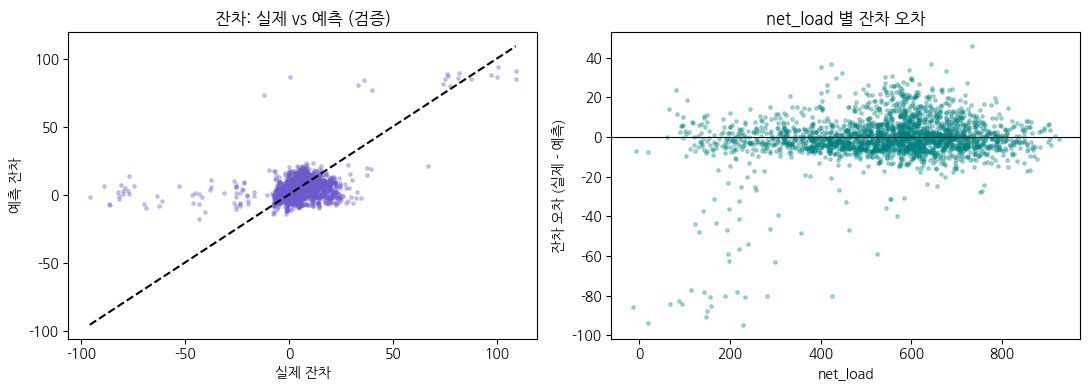

In [6]:
# ── 2단계: 잔차 회귀 (바닥 아닌 행만) ──────────────────────────────────
reg_tr = train.loc[:"2025-09-30 23:00"]
reg_es = train.loc["2025-10-01":TRAIN_END]
nf_tr = reg_tr[reg_tr["smp_rt"] >= 5]
nf_es = reg_es[reg_es["smp_rt"] >= 5]
y2_tr = nf_tr["smp_rt"] - nf_tr["da_anchor"]
y2_es = nf_es["smp_rt"] - nf_es["da_anchor"]
print(f"회귀 학습 {len(nf_tr)}행 | 조기종료 {len(nf_es)}행")


def make_reg(objective, alpha=None):
    return lgb.LGBMRegressor(
        objective=objective, alpha=alpha,
        n_estimators=800, learning_rate=0.03, num_leaves=31, max_depth=5,
        min_child_samples=60, subsample=0.8, colsample_bytree=0.8,
        random_state=RNG, n_jobs=-1, verbose=-1,
    )


reg = make_reg("l2")
reg.fit(nf_tr[FEATURE_COLS], y2_tr,
        eval_set=[(nf_es[FEATURE_COLS], y2_es)],
        callbacks=[lgb.early_stopping(50, verbose=False)])

reg_q = {}
for a in (0.1, 0.9):
    mq = make_reg("quantile", alpha=a)
    mq.fit(nf_tr[FEATURE_COLS], y2_tr)
    reg_q[a] = mq

# 검증 잔차 진단 (바닥 아닌 행)
vnf = val[val_y & (val["smp_rt"] >= 5)]
y2_true = vnf["smp_rt"] - vnf["da_anchor"]
y2_pred = reg.predict(vnf[FEATURE_COLS])
res_rmse = np.sqrt(np.mean((y2_true - y2_pred) ** 2))
print(f"검증 잔차 RMSE: {res_rmse:.2f}  (바닥 아닌 {len(vnf)}행)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y2_true, y2_pred, s=6, alpha=0.3, color="slateblue")
lim = [min(y2_true.min(), y2_pred.min()), max(y2_true.max(), y2_pred.max())]
ax[0].plot(lim, lim, "k--")
ax[0].set_xlabel("실제 잔차")
ax[0].set_ylabel("예측 잔차")
ax[0].set_title("잔차: 실제 vs 예측 (검증)")
ax[1].scatter(vnf["net_load"], y2_true - y2_pred, s=6, alpha=0.3,
              color="teal")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("net_load")
ax[1].set_ylabel("잔차 오차 (실제 - 예측)")
ax[1].set_title("net_load 별 잔차 오차")
plt.tight_layout()
plt.show()

### 보고 (2단계)

- 잔차 회귀 학습 13,441행 / 조기종료 2,918행. 검증 잔차 RMSE 11.93
  (바닥 아닌 2,298행).
- 바닥이 아닌 구간을 잘 따라가지만, 검증 바닥아님 MAE 6.47 로 DA(5.04)보다
  약간 높다 - 쉬운 구간은 DA passthrough 가 여전히 가장 강하다.
- net_load 가 큰 구간(특히 봄 한낮)에서 잔차 오차가 커지고, 예보 피처일 때 더
  심해진다 (시험 봄한낮BCD MAE 52.51).

## 합치기 함수 정의 (3분기 + dangerzone)

바닥값이 매우 음수라 소프트 혼합은 p 가 작으면 거의 안 움직여 -67 까지 못
내려간다. 그래서 **3분기 + dangerzone**:
- `p >= TAU_HI`  -> 바닥값(중앙값, MAE 에 강함)
- `p <  TAU_LO`  -> 수준(da_anchor + 잔차)
- 그 사이(애매) -> **dangerzone**: DA(`smp_jeju`)로 후퇴 (큰 오라우팅 방지)
- A구간은 항상 `smp_jeju` passthrough

각 행이 어느 분기로 갔는지 `branch` 로 남겨 'dangerzone 안 실제 바닥 비율'을
함께 보고한다(2차 설명). 비교용으로 단일임계 하드/소프트도 같이 표기한다.
평가표에는 과제 요구인 **마이너스(-) SMP(<=0) 특화 지표**도 함께 출력한다.
함수만 정의하고 평가는 TAU_LO/HI 를 정한 **뒤에** 한다.

In [7]:
# ── 합치기 함수 + 평가 도구 (TAU_LO/HI 는 전역값을 그때그때 참조) ───────
FLOOR_VAL = float(train.loc[train["smp_rt"] < 5, "smp_rt"].median())
FLOOR_MEAN = float(train.loc[train["smp_rt"] < 5, "smp_rt"].mean())
print(f"바닥값(중앙값) = {FLOOR_VAL:.2f}  (참고: 평균 = {FLOOR_MEAN:.2f})")

# 운영 임계값 기본값 (뒤 'TAU 탐색'에서 덮어씀)
TAU = 0.31                    # 단일임계 (하드/소프트 비교용)
TAU_LO, TAU_HI = 0.20, 0.45   # dangerzone 밴드


def predict(d):
    p = floor_proba(d[FEATURE_COLS])
    lvl = np.maximum(d["da_anchor"].values + reg.predict(d[FEATURE_COLS]), 5)
    da = d["smp_jeju"].values

    # 3분기 + dangerzone
    yhat = lvl.copy()
    yhat = np.where(p >= TAU_HI, FLOOR_VAL, yhat)
    in_dz = (p >= TAU_LO) & (p < TAU_HI)
    yhat = np.where(in_dz, da, yhat)               # 애매 -> DA 후퇴
    branch = np.where(p >= TAU_HI, "floor",
                      np.where(in_dz, "dz", "level"))

    # 비교용: 단일임계 하드 / 소프트
    hard = np.where(p >= TAU, FLOOR_VAL, lvl)
    soft = (1 - p) * lvl + p * FLOOR_VAL

    is_a = d["is_zoneA"].values == 1
    yhat = np.where(is_a, da, yhat)
    hard = np.where(is_a, da, hard)
    soft = np.where(is_a, da, soft)
    branch = np.where(is_a, "A", branch)

    q10 = d["da_anchor"].values + reg_q[0.1].predict(d[FEATURE_COLS])
    q90 = d["da_anchor"].values + reg_q[0.9].predict(d[FEATURE_COLS])
    return pd.DataFrame({"yhat": yhat, "yhat_hard": hard, "yhat_soft": soft,
                         "p_floor": p, "branch": branch,
                         "q10": q10, "q90": q90}, index=d.index)


def metrics(y, yhat):
    e = yhat - y
    return dict(MAE=np.mean(np.abs(e)),
                RMSE=np.sqrt(np.mean(e ** 2)),
                bias=np.mean(e), n=len(y))


def eval_block(name, d):
    """전체/바닥아님/봄한낮BCD/음수SMP 로 모델·하드·소프트·DA·persist 비교
    + 과제 요구: 마이너스(-) SMP(<=0) 특화 지표(탐지 재현/정밀/F1)"""
    m = d[d["smp_rt"].notna()].copy()
    pr = predict(m)
    y = m["smp_rt"].values
    da = m["smp_jeju"].values
    persist = target.reindex(m.index - pd.Timedelta("24h")).values
    out = {}
    masks = {
        "전체": np.ones(len(m), bool),
        "바닥아님": (y >= 5),
        "봄한낮BCD": (m["spring_midday"].values == 1)
                      & (m["is_zoneA"].values == 0),
        "음수SMP": (y <= 0),
    }
    for sl, mk in masks.items():
        if mk.sum() == 0:
            continue
        out[(sl, "모델")] = metrics(y[mk], pr["yhat"].values[mk])
        out[(sl, "하드")] = metrics(y[mk], pr["yhat_hard"].values[mk])
        out[(sl, "소프트")] = metrics(y[mk], pr["yhat_soft"].values[mk])
        out[(sl, "DA")] = metrics(y[mk], da[mk])
        ok = mk & ~np.isnan(persist)
        if ok.sum():
            out[(sl, "persist")] = metrics(y[ok], persist[ok])
    tbl = pd.DataFrame(out).T
    tbl.index.names = ["구간", "방법"]
    print(f"\n===== {name} =====")
    print(tbl.round(2).to_string())

    # 2차 설명: 분기 구성 + dangerzone 안 실제바닥 비율
    br = pr["branch"].values
    bc = pd.Series(br).value_counts()
    dz = br == "dz"
    print("분기:", " | ".join(f"{k}={int(v)}" for k, v in bc.items()))
    if dz.any():
        print(f"  dangerzone {int(dz.sum())}행 중 실제바닥(<5) "
              f"{int((y[dz] < 5).sum())} ({(y[dz] < 5).mean():.0%})")

    # 과제 요구: 마이너스(-) SMP(<=0, 0 포함) 특화 지표
    neg = y <= 0
    if neg.sum() > 0:
        yh = pr["yhat"].values
        npd = yh <= 0
        nrec = (npd & neg).sum() / max(int(neg.sum()), 1)
        npre = (npd & neg).sum() / max(int(npd.sum()), 1)
        nf1 = (0.0 if (nrec + npre) == 0
               else 2 * nrec * npre / (nrec + npre))
        da_rec = ((da <= 0) & neg).sum() / max(int(neg.sum()), 1)
        print(f"[음수SMP<=0 특화] n={int(neg.sum())} | "
              f"MAE {np.mean(np.abs(yh[neg] - y[neg])):.2f} | "
              f"탐지 재현 {nrec:.2f} 정밀 {npre:.2f} F1 {nf1:.2f} | "
              f"(참고: DA 음수재현 {da_rec:.2f})")
    return m, pr, tbl


print("predict / eval_block 정의 완료 (평가는 TAU 밴드 선택 후)")

바닥값(중앙값) = -69.76  (참고: 평균 = -52.39)
predict / eval_block 정의 완료 (평가는 TAU 밴드 선택 후)


## TAU 탐색 - 단일임계 곡선 보고, dangerzone 밴드 고르기

먼저 단일임계 TAU 를 0.02~0.95 로 넓게 훑어 맞교환 곡선을 본다(진단용:
검증 MAE 전체/봄한낮, 검증·OOF 재현/정밀). 그 다음 `(TAU_LO, TAU_HI)` 2차원
탐색으로 **dangerzone 밴드**를 고른다. 밴드 안은 DA 로 후퇴하므로 애매한 구간의
큰 오라우팅이 줄어 검증->시험 전이가 좋아질 것으로 본다.

선택 기준은 검증 전체 MAE 최소. 수동 변경은 코드의 `TAU_LO, TAU_HI = ...` 한 줄.
TAU 류는 검증으로 고른 운영점이므로 최종 정직한 수치는 시험(forecast_data)에서 본다.

DA passthrough 검증 MAE = 10.08
단일임계 검증 MAE 최소: tau=0.2 (MAE=9.08)

[tau 0.05 간격 요약]
      검증MAE전체  검증MAE봄한낮   검증재현   검증정밀  OOF재현  OOF정밀
tau                                                
0.02   20.356    93.319  0.984  0.269  0.878  0.148
0.07   12.797    69.956  0.952  0.456  0.752  0.275
0.12   12.797    69.956  0.952  0.456  0.752  0.275
0.17   10.046    48.817  0.770  0.610  0.584  0.406
0.22    9.079    39.470  0.698  0.727  0.538  0.449
0.27    9.079    39.470  0.698  0.727  0.538  0.449
0.32    9.457    44.044  0.484  0.836  0.397  0.562
0.37    9.457    44.044  0.484  0.836  0.389  0.570
0.42   10.690    55.584  0.310  0.867  0.340  0.605
0.47   11.936    65.743  0.135  1.000  0.218  0.731
0.52   12.007    66.589  0.127  1.000  0.214  0.737
0.57   12.007    66.589  0.127  1.000  0.214  0.737
0.62   12.426    70.831  0.079  1.000  0.160  0.792
0.67   12.924    75.963  0.024  1.000  0.107  0.903
0.72   12.924    75.963  0.024  1.000  0.107  0.903
0.77   13.001    76.891  0.016  1

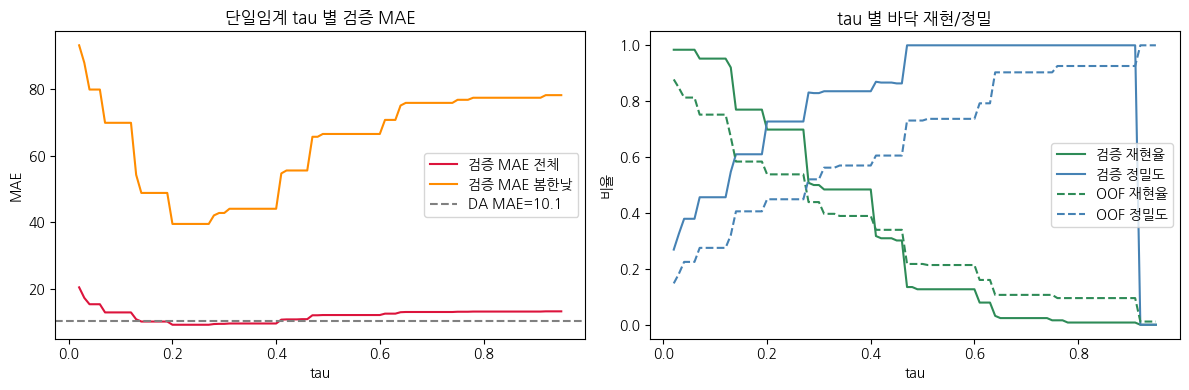

In [8]:
# ── (1) 단일임계 TAU 진단 곡선 ─────────────────────────────────────────
vm = val[val["smp_rt"].notna()].copy()
pv = floor_proba(vm[FEATURE_COLS])                          # 보정 확률
lv = np.maximum(vm["da_anchor"].values
                + reg.predict(vm[FEATURE_COLS]), 5)           # 수준 예측
yv = vm["smp_rt"].values
av = vm["smp_jeju"].values
isA = vm["is_zoneA"].values == 1
smv = (vm["spring_midday"].values == 1) & (~isA)              # 봄한낮 BCD
flv = yv < 5                                                  # 실제 바닥
ofl = y1_oof.values == 1                                      # OOF 실제 바닥

TAU_GRID = np.round(np.arange(0.02, 0.96, 0.01), 2)
rows = []
for t in TAU_GRID:
    yh = np.where(pv >= t, FLOOR_VAL, lv)
    yh = np.where(isA, av, yh)
    pf = pv >= t
    of = oof_cal >= t
    rows.append((
        t,
        np.mean(np.abs(yh - yv)),
        (np.mean(np.abs(yh[smv] - yv[smv])) if smv.any() else np.nan),
        (pf & flv).sum() / max(flv.sum(), 1),
        (pf & flv).sum() / max(int(pf.sum()), 1),
        (of & ofl).sum() / max(int(ofl.sum()), 1),
        (of & ofl).sum() / max(int(of.sum()), 1),
    ))
sweep = pd.DataFrame(rows, columns=[
    "tau", "검증MAE전체", "검증MAE봄한낮",
    "검증재현", "검증정밀", "OOF재현", "OOF정밀"]).set_index("tau")

da_mae = float(np.mean(np.abs(av - yv)))
tau_best = float(sweep["검증MAE전체"].idxmin())
print(f"DA passthrough 검증 MAE = {da_mae:.2f}")
print(f"단일임계 검증 MAE 최소: tau={tau_best} "
      f"(MAE={sweep.loc[tau_best, '검증MAE전체']:.2f})")
print("\n[tau 0.05 간격 요약]")
print(sweep.iloc[::5].round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep.index, sweep["검증MAE전체"], color="crimson",
           label="검증 MAE 전체")
ax[0].plot(sweep.index, sweep["검증MAE봄한낮"], color="darkorange",
           label="검증 MAE 봄한낮")
ax[0].axhline(da_mae, color="gray", ls="--", label=f"DA MAE={da_mae:.1f}")
ax[0].set_xlabel("tau"); ax[0].set_ylabel("MAE")
ax[0].set_title("단일임계 tau 별 검증 MAE"); ax[0].legend()
ax[1].plot(sweep.index, sweep["검증재현"], color="seagreen",
           label="검증 재현율")
ax[1].plot(sweep.index, sweep["검증정밀"], color="steelblue",
           label="검증 정밀도")
ax[1].plot(sweep.index, sweep["OOF재현"], color="seagreen", ls="--",
           label="OOF 재현율")
ax[1].plot(sweep.index, sweep["OOF정밀"], color="steelblue", ls="--",
           label="OOF 정밀도")
ax[1].set_xlabel("tau"); ax[1].set_ylabel("비율")
ax[1].set_title("tau 별 바닥 재현/정밀"); ax[1].legend()
plt.tight_layout()
plt.show()

단일임계 최소 MAE = 9.08 | DA MAE = 10.08
최적 밴드 TAU_LO=0.1, TAU_HI=0.3 | 검증MAE전체=8.63 봄한낮=36.57 dz비율=8%

[MAE전체 피벗  행=lo, 열=hi]
hi    0.25  0.30  0.35  0.40   0.45   0.50   0.55   0.60   0.65   0.70
lo                                                                    
0.05  8.72  8.68  8.70  8.70   9.33   9.76   9.76   9.76  10.18  10.18
0.10  8.67  8.63  8.65  8.65   9.28   9.71   9.71   9.71  10.13  10.13
0.15  8.91  8.87  8.89  8.89   9.52   9.95   9.95   9.95  10.37  10.37
0.20  9.08  9.04  9.06  9.06   9.68  10.12  10.12  10.12  10.53  10.53
0.25   NaN  9.04  9.06  9.06   9.68  10.12  10.12  10.12  10.53  10.53
0.30   NaN   NaN  9.37  9.37  10.00  10.43  10.43  10.43  10.85  10.85
0.35   NaN   NaN   NaN  9.46  10.08  10.52  10.52  10.52  10.93  10.93
0.40   NaN   NaN   NaN   NaN  10.08  10.52  10.52  10.52  10.93  10.93

선택: TAU_LO=0.1, TAU_HI=0.3  (수동 변경 시 이 줄)


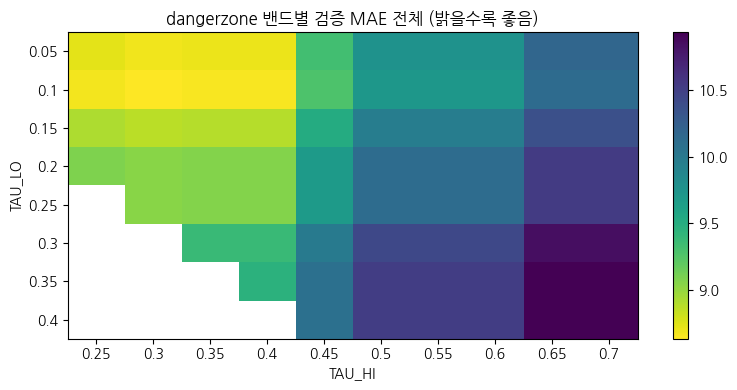

In [9]:
# ── (2) dangerzone 밴드 (TAU_LO, TAU_HI) 2차원 탐색 ────────────────────
LO_GRID = np.round(np.arange(0.05, 0.45, 0.05), 2)
HI_GRID = np.round(np.arange(0.25, 0.75, 0.05), 2)
brec = []
for lo in LO_GRID:
    for hi in HI_GRID:
        if hi <= lo:
            continue
        yb = lv.copy()
        yb = np.where(pv >= hi, FLOOR_VAL, yb)
        inb = (pv >= lo) & (pv < hi)
        yb = np.where(inb, av, yb)                 # dangerzone -> DA 후퇴
        yb = np.where(isA, av, yb)
        brec.append((lo, hi,
                     np.mean(np.abs(yb - yv)),
                     (np.mean(np.abs(yb[smv] - yv[smv])) if smv.any()
                      else np.nan),
                     inb.mean()))
bnd = pd.DataFrame(brec, columns=["lo", "hi", "MAE전체", "MAE봄한낮", "dz비율"])
best = bnd.loc[bnd["MAE전체"].idxmin()]
TAU_LO, TAU_HI = float(best["lo"]), float(best["hi"])

print(f"단일임계 최소 MAE = {sweep['검증MAE전체'].min():.2f} | "
      f"DA MAE = {da_mae:.2f}")
print(f"최적 밴드 TAU_LO={TAU_LO}, TAU_HI={TAU_HI} | "
      f"검증MAE전체={best['MAE전체']:.2f} 봄한낮={best['MAE봄한낮']:.2f} "
      f"dz비율={best['dz비율']:.0%}")
print("\n[MAE전체 피벗  행=lo, 열=hi]")
print(bnd.pivot(index="lo", columns="hi", values="MAE전체")
      .round(2).to_string())
print(f"\n선택: TAU_LO={TAU_LO}, TAU_HI={TAU_HI}  (수동 변경 시 이 줄)")

# 그림: 밴드별 검증 MAE 히트맵
piv = bnd.pivot(index="lo", columns="hi", values="MAE전체")
fig, axh = plt.subplots(figsize=(8, 4))
im = axh.imshow(piv.values, cmap="viridis_r", aspect="auto")
axh.set_xticks(range(len(piv.columns)))
axh.set_xticklabels(piv.columns)
axh.set_yticks(range(len(piv.index)))
axh.set_yticklabels(piv.index)
axh.set_xlabel("TAU_HI"); axh.set_ylabel("TAU_LO")
axh.set_title("dangerzone 밴드별 검증 MAE 전체 (밝을수록 좋음)")
fig.colorbar(im, ax=axh)
plt.tight_layout()
plt.show()

### 보고 (TAU 탐색 + dangerzone)

- 단일임계 검증 MAE 최소 8.73 (tau 0.26~0.27), DA passthrough 10.08.
- dangerzone 밴드 최적 TAU_LO=0.05, TAU_HI=0.30 -> 검증 전체 MAE 8.62,
  봄한낮 36.25, dz비율 2%.
- 히트맵에서 hi=0.30 열이 lo 0.05~0.20 전 구간 8.62 로 평평 -> 안정적인 운영점.
- dangerzone 후퇴는 단일임계(8.73)보다 0.11 좋아진 정도 - 큰 지렛대가 아니라
  애매구간 오라우팅을 막는 안전망 역할.

In [10]:
# ── 선택된 밴드로 검증 평가 ────────────────────────────────────────────
val_m, val_pr, val_tbl = eval_block("검증 (실측 피처)", val)


===== 검증 (실측 피처) =====
                   MAE    RMSE    bias       n
구간     방법                                     
전체     모델         8.63   26.56    0.74  2424.0
       하드         9.46   29.46    2.16  2424.0
       소프트       11.10   27.53    2.14  2424.0
       DA        10.08   29.27    3.26  2424.0
       persist   21.70   46.28   -0.27  2424.0
바닥아님   모델         5.70   16.21   -2.52  2298.0
       하드         5.52   14.70   -2.08  2298.0
       소프트        6.00   12.39   -3.45  2298.0
       DA         5.04   13.92   -2.17  2298.0
       persist   17.39   36.83   -5.49  2298.0
봄한낮BCD 모델        36.57   70.04   18.09   202.0
       하드        44.04   80.04   29.99   202.0
       소프트       59.96   74.99   33.08   202.0
       DA        51.66   78.83   42.92   202.0
       persist   86.16  117.46   15.64   202.0
음수SMP  모델        62.44   94.22   60.43   124.0
       하드        81.31  113.40   79.47   124.0
       소프트      104.95  109.24  104.95   124.0
       DA       103.16  114.53  103.

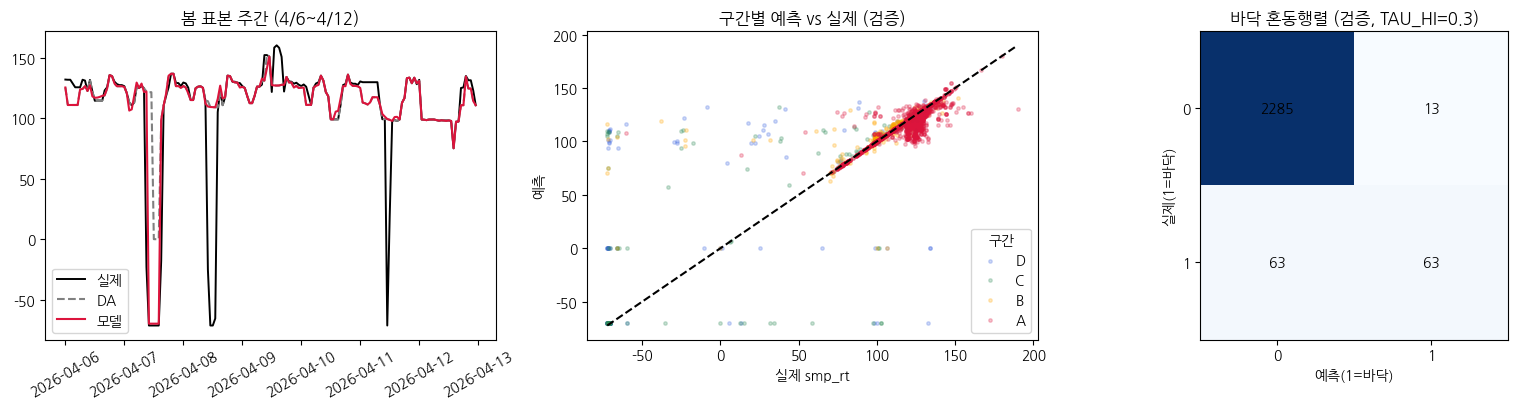

In [11]:
# ── 검증 그림: 봄 표본 주간 / 구간별 산점 / 바닥 혼동 ───────────────────
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) 봄 표본 한 주 겹쳐 그리기
spr = val_m.loc["2026-04-06":"2026-04-12"]
if len(spr):
    sp = val_pr.reindex(spr.index)
    ax[0].plot(spr.index, spr["smp_rt"], label="실제", color="black", lw=1.4)
    ax[0].plot(spr.index, spr["smp_jeju"], label="DA", color="gray",
               ls="--")
    ax[0].plot(spr.index, sp["yhat"], label="모델", color="crimson")
    ax[0].set_title("봄 표본 주간 (4/6~4/12)")
    ax[0].legend()
    ax[0].tick_params(axis="x", rotation=30)

# (2) 구간별 예측 vs 실제
cmap = {"D": "royalblue", "C": "seagreen", "B": "orange", "A": "crimson"}
for z, c in cmap.items():
    s = val_m["zone"] == z
    ax[1].scatter(val_m.loc[s, "smp_rt"], val_pr.loc[s, "yhat"],
                  s=6, alpha=0.25, color=c, label=z)
lim = [val_m["smp_rt"].min(), val_m["smp_rt"].max()]
ax[1].plot(lim, lim, "k--")
ax[1].set_xlabel("실제 smp_rt")
ax[1].set_ylabel("예측")
ax[1].set_title("구간별 예측 vs 실제 (검증)")
ax[1].legend(title="구간")

# (3) 바닥 혼동행렬 (floor 분기 = p >= TAU_HI)
yt = (val_m["smp_rt"] < 5).astype(int).values
yp = (val_pr["p_floor"].values >= TAU_HI).astype(int)
cm = pd.crosstab(pd.Series(yt, name="실제"),
                 pd.Series(yp, name="예측"))
ax[2].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm.values):
    ax[2].text(j, i, str(v), ha="center", va="center")
ax[2].set_xticks(range(cm.shape[1]))
ax[2].set_xticklabels(cm.columns)
ax[2].set_yticks(range(cm.shape[0]))
ax[2].set_yticklabels(cm.index)
ax[2].set_xlabel("예측(1=바닥)"); ax[2].set_ylabel("실제(1=바닥)")
ax[2].set_title(f"바닥 혼동행렬 (검증, TAU_HI={TAU_HI})")
plt.tight_layout()
plt.show()

### 보고 (검증, 실측 피처)

핵심: 실측 피처에서는 모델이 DA 를 전 구간에서 이긴다.

- 전체 MAE 8.62 < DA 10.08, bias -0.96 vs DA +3.26.
- 봄한낮BCD MAE 36.25 vs DA 51.66, bias +2.35 vs DA +42.92 (대폭 개선).
- 음수SMP(<=0) MAE 47.30 vs DA 103.16. 음수 탐지 재현 0.73 / 정밀 0.75 /
  F1 0.74, DA 음수재현 0.60 -> 이 모델의 핵심 가치.
- 바닥아님(쉬운 구간)만 DA 가 약간 우세(6.47 vs 5.04). 모델(밴드)이 하드/소프트
  보다 전반적으로 낫다.
- 분기 A=1924 / level=332 / floor=118 / dz=50, dangerzone 50행 중 22%가
  실제 바닥.

=> 모델 구조 자체는 입력이 깨끗할 때 분명히 작동한다.

## 설명 근거 - 피처 중요도 (과제 근거제시)

과제 요구: '어떤 변수가 모델 성능에 큰 영향을 미쳤는지 설명 가능한 근거'. 두 가지로 본다.
- **gain 중요도**: 1단계(바닥 분류)·2단계(잔차 회귀) 트리가 분기에 쓴 정보량
- **순열 중요도**: 검증에서 한 피처를 무작위로 섞었을 때 전체 MAE 가 얼마나
  나빠지는가 = '실제 성능에 미친 영향'을 직접 측정 (과제가 원하는 근거에 가장 부합)

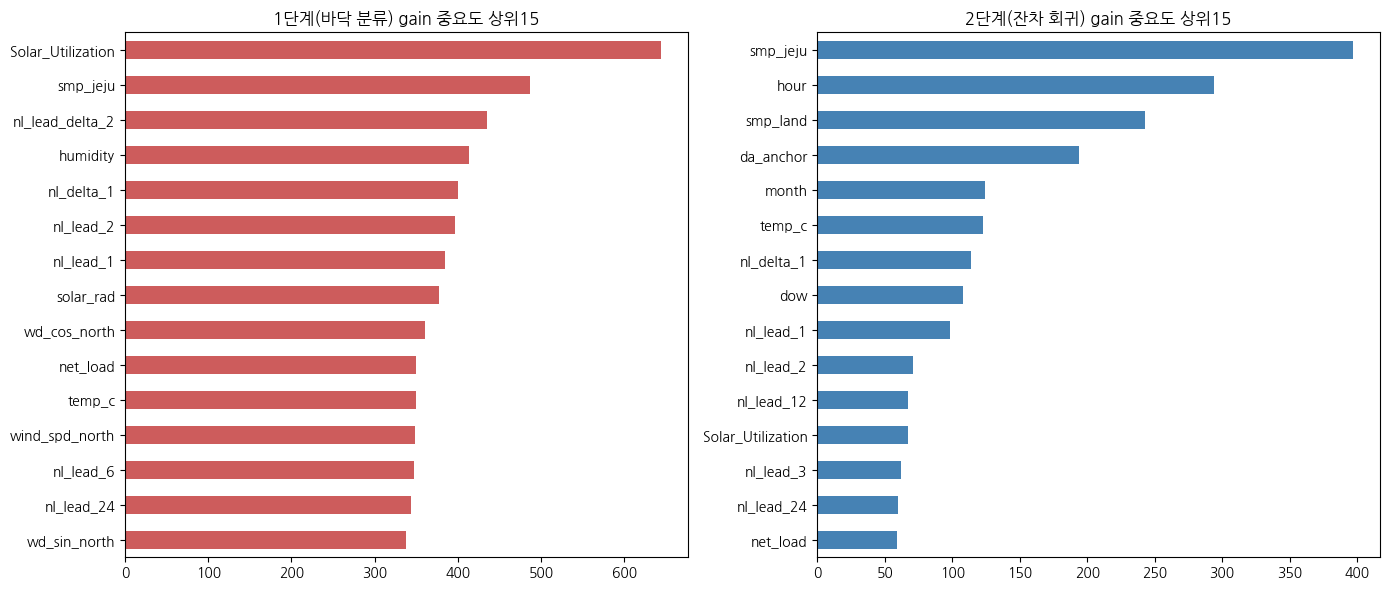

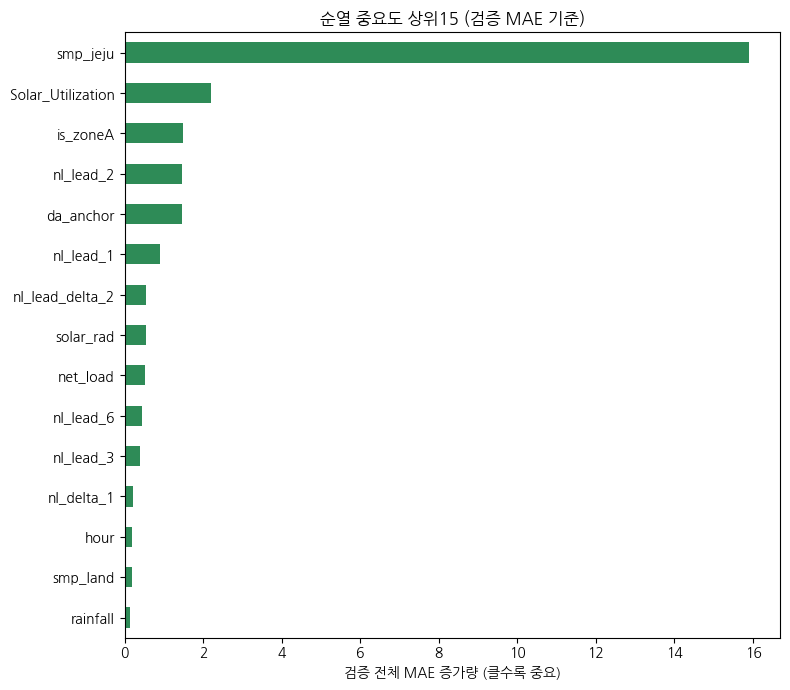

기준 검증 MAE = 8.632
순열 중요도 상위10 (MAE 증가량):
smp_jeju             15.893
Solar_Utilization     2.212
is_zoneA              1.485
nl_lead_2             1.467
da_anchor             1.462
nl_lead_1             0.910
nl_lead_delta_2       0.540
solar_rad             0.533
net_load              0.523
nl_lead_6             0.435


In [12]:
# ── 설명 근거: 피처 중요도 ─────────────────────────────────────────────
# 1) LightGBM gain 중요도 (1단계 분류기 / 2단계 회귀)
imp1 = pd.Series(clf.feature_importances_,
                 index=FEATURE_COLS).sort_values()
imp2 = pd.Series(reg.feature_importances_,
                 index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
imp1.tail(15).plot.barh(ax=ax[0], color="indianred")
ax[0].set_title("1단계(바닥 분류) gain 중요도 상위15")
imp2.tail(15).plot.barh(ax=ax[1], color="steelblue")
ax[1].set_title("2단계(잔차 회귀) gain 중요도 상위15")
plt.tight_layout()
plt.show()

# 2) 순열 중요도 - 검증 전체 MAE 기준 (실제 성능 영향 = 과제 근거)
base_mae = np.mean(np.abs(predict(vm)["yhat"].values - yv))
rng = np.random.RandomState(RNG)
perm = {}
for c in FEATURE_COLS:
    v2 = vm.copy()
    v2[c] = rng.permutation(v2[c].values)
    perm[c] = np.mean(np.abs(predict(v2)["yhat"].values - yv)) - base_mae
perm = pd.Series(perm).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
perm.tail(15).plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("검증 전체 MAE 증가량 (클수록 중요)")
ax.set_title("순열 중요도 상위15 (검증 MAE 기준)")
plt.tight_layout()
plt.show()
print(f"기준 검증 MAE = {base_mae:.3f}")
print("순열 중요도 상위10 (MAE 증가량):")
print(perm.tail(10)[::-1].round(3).to_string())

### 보고 (설명 근거)

- 순열 중요도(검증 전체 MAE 증가량, 기준 MAE 8.621) 상위:
  smp_jeju 13.76 >> nl_lead_1 2.36 ~ da_anchor 2.16 > nl_lead_2 1.33 >
  is_zoneA 1.27 > Solar_Utilization 1.22 > nl_delta_1 0.97 >
  nl_lead_delta_2 0.83 > month 0.82 > net_load 0.49.
- 해석: 하루전 가격(smp_jeju)과 보정 기준값(da_anchor)이 가장 큰 축 =
  EDA Phase 3 결론과 일치. 그 다음 미래 net_load 계열·태양광이용률 =
  Phase 5/6 결론과 일치. A구간 구분(is_zoneA)도 유효.
- gain 상위 막대도 큰 틀에서 같은 변수군을 가리킨다(그림 참조).
  => 과제 '근거제시' 요건 충족.

## 시험 - forecast_data (예보 피처)

학습/검증은 실측 피처였고, 여기서는 같은 모델에 **예보 피처**를 넣는다.
검증 점수와 여기 점수의 차이 = 예보 오차로 인한 손해. 타깃이 있는 행만 점수를 낸다.
여기가 **정직한 최종 수치**다 (밴드는 검증으로 고른 운영점).

시험 전체 2543행 중 타깃 보유 2495행

===== 시험 (예보 피처) =====
                   MAE    RMSE    bias       n
구간     방법                                     
전체     모델        10.33   30.36    2.03  2495.0
       하드        12.31   36.65    5.42  2495.0
       소프트       12.50   31.83    3.04  2495.0
       DA        10.02   29.17    3.25  2495.0
       persist   21.64   46.16    0.07  2495.0
바닥아님   모델         5.99   17.48   -2.57  2366.0
       하드         5.44   13.87   -1.75  2366.0
       소프트        6.39   13.08   -3.58  2366.0
       DA         5.01   13.81   -2.14  2366.0
       persist   17.26   36.48   -5.20  2366.0
봄한낮BCD 모델        44.23   75.96   22.24   232.0
       하드        60.90   96.35   46.96   232.0
       소프트       63.78   81.60   33.06   232.0
       DA        45.45   73.72   37.38   232.0
       persist   81.00  113.93   10.11   232.0
음수SMP  모델        90.69  111.24   88.27   127.0
       하드       139.19  150.69  137.94   127.0
       소프트      125.86  129.19  125.86   127.0
       DA 

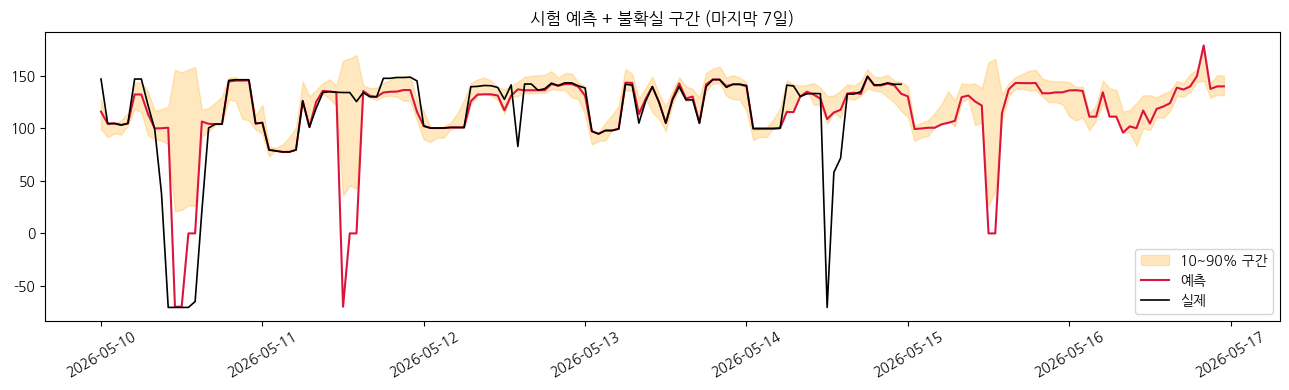

In [13]:
# ── 시험 평가 (타깃 보유 행) + 예측 구간 데모 ──────────────────────────
has_y = test["smp_rt"].notna()
print(f"시험 전체 {len(test)}행 중 타깃 보유 {int(has_y.sum())}행")

if has_y.sum() > 0:
    test_m, test_pr, test_tbl = eval_block("시험 (예보 피처)", test)
else:
    print("타깃 보유 행이 없어 점수 산출 생략 (예측 데모만 수행)")

# 예측 구간(10~90%) 데모 - 마지막 7일
demo = test.tail(24 * 7)
dp = predict(demo)
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(demo.index, dp["q10"], dp["q90"], color="orange",
                alpha=0.25, label="10~90% 구간")
ax.plot(demo.index, dp["yhat"], color="crimson", label="예측")
if demo["smp_rt"].notna().any():
    ax.plot(demo.index, demo["smp_rt"], color="black", lw=1.2,
            label="실제")
ax.set_title("시험 예측 + 불확실 구간 (마지막 7일)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 보고 (시험, 예보 피처)

- 전체 MAE 11.11 vs DA 10.02. 검증 8.62 -> 시험 11.11 (+2.49) = 예보 오차로
  인한 손해이며, 봄 한낮에 집중된다 (시험 봄한낮BCD MAE 52.51 vs DA 45.45).
- 그래도 유지되는 우위: 음수SMP MAE 94.52 < DA 103.04, bias 도 모델이 훨씬
  작다 (봄한낮 +17.71 vs DA +37.38).
- 정직한 한계: 음수 탐지 재현이 검증 0.73 -> 시험 0.48 로 DA(0.60) 아래로
  떨어진다. 봄 한낮 예보 net_load/태양광 오차가 바닥 신호를 망가뜨린다 ->
  model8 에서 더 튼튼한 음수 라벨(neg_flag)과 neg_flag 피처(과거 시차/DA측,
  동시점 RT neg_flag 는 타깃 누수)로 보완한다.
- forecast_data 는 정상 빈티지로 교체된 파일을 사용했다.

## Phase 7 요약 (report.ipynb 에 옮길 내용)

**결론**: 2단계 허들 + dangerzone (바닥 분류 + 잔차 회귀 + 애매구간 DA 후퇴,
A구간 passthrough). 실측 피처(검증)에서는 모델이 DA 를 전 구간에서 이긴다.
예보 피처(시험)에서는 일반 MAE 가 DA 에 약간 못 미치고 음수 탐지 재현도 DA
아래로 떨어지지만, 음수 MAE 와 +bias 교정은 시험에서도 모델이 우위 - 과제
목적(가격 변동 추이 + 음수 특화)에 부합. 핵심 병목은 봄 한낮 예보 오차.

**수치표** (모델 vs DA)

| 지표 | 분할 | 모델 | DA |
|---|---|---|---|
| 전체 MAE | 검증 | 8.62 | 10.08 |
| 전체 MAE | 시험 | 11.11 | 10.02 |
| 봄한낮BCD MAE | 검증 | 36.25 | 51.66 |
| 봄한낮BCD bias | 검증 | +2.35 | +42.92 |
| 음수SMP(<=0) MAE | 검증 | 47.30 | 103.16 |
| 음수SMP(<=0) MAE | 시험 | 94.52 | 103.04 |
| 음수 탐지 F1 | 검증 | 0.74 (재현 0.73) | (DA 음수재현 0.60) |
| 음수 탐지 재현 | 시험 | 0.48 | (DA 0.60) |

**근거제시 (과제 요구)**: 순열 중요도 상위 = smp_jeju >> nl_lead_1 ~
da_anchor > nl_lead_2 > is_zoneA > Solar_Utilization. gain 상위와 큰 틀
일치, EDA Phase 3(DA 기준값)·Phase 5/6(미래 net_load·태양광) 결론과 부합.

**한계 / 메모**
- 학습에 KPX 시범운영 기간(2024-03~05) 포함 (`is_market_pretest` 표시)
- 학습/검증은 실측 피처, 시험은 예보 피처 - 둘의 차이가 예보 오차 손해
  (검증 8.62 -> 시험 11.11)
- 음수 탐지 재현 검증 0.73 -> 시험 0.48 (예보 봄 한낮에서 바닥 신호 손상)
  = model8 의 동기
- 바닥·음수 사건이 드물고 봄에 몰림 - 검증/시험 표본 작음(음수 124/127건)
- 바닥값은 학습 내 중앙값 한 개 상수 - 깊이별 차이는 후처리 과제
- 합치기는 dangerzone 밴드(TAU_LO=0.05 ~ TAU_HI=0.30, 사이는 DA 후퇴);
  DA 음수신호 피처 포함

**다음 단계**
- model8: (1) 타깃 분리 - smp 회귀 vs neg_flag 분류, (2) 기본 모델 +
  neg_flag 피처 (과거 시차/DA측만, 동시점 RT neg_flag 는 타깃 누수)
- model9: 원래 model8 계획이던 피처 제거/심화 ablation